<a href="https://www.kaggle.com/code/aamir28/eco-anxiety-carbon-footprint-analysis?scriptVersionId=332044382" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #0B3D5C 0%, #4F3D4A 55%, #C4542A 100%); padding: 42px 38px; border-radius: 14px; color: white; font-family: 'Helvetica Neue', Arial, sans-serif; box-shadow: 0 6px 18px rgba(0,0,0,0.18);">
  <h1 style="margin:0; font-size: 32px; letter-spacing: 0.3px;">🌍 Eco-Anxiety &amp; Carbon Footprint Survey (2026)</h1>
  <p style="margin: 12px 0 0 0; font-size: 16px; line-height:1.5; opacity: 0.94; max-width: 760px;">
    What does a person's day-to-day lifestyle have to do with how anxious they feel about the climate?
    This notebook explores 800 survey respondents across 27 countries — combining consumption habits,
    extreme-weather exposure, and climate psychology — with full EDA, feature engineering, and two
    predictive models.
  </p>
  <div style="margin-top:20px;">
    <span style="background: rgba(255,255,255,0.16); padding: 6px 14px; border-radius: 20px; font-size: 12px; margin-right:8px;">Exploratory Data Analysis</span>
    <span style="background: rgba(255,255,255,0.16); padding: 6px 14px; border-radius: 20px; font-size: 12px; margin-right:8px;">Feature Engineering</span>
    <span style="background: rgba(255,255,255,0.16); padding: 6px 14px; border-radius: 20px; font-size: 12px; margin-right:8px;">Regression Modeling</span>
    <span style="background: rgba(255,255,255,0.16); padding: 6px 14px; border-radius: 20px; font-size: 12px;">Climate Psychology</span>
  </div>
</div>

<div style="background:#F7F4F0; border:1px solid #E3DDD3; border-radius: 10px; padding: 18px 22px; margin-top: 16px;">
<b>📑 Table of Contents</b>
<ol style="margin-top:10px; line-height:1.9;">
<li><a href="#intro">Introduction &amp; Questions</a></li>
<li><a href="#setup">Setup</a></li>
<li><a href="#load">Load the Data</a></li>
<li><a href="#quality">Data Quality Check</a></li>
<li><a href="#cleaning">Cleaning &amp; Imputation</a></li>
<li><a href="#demographics">Who Took the Survey? (Demographics)</a></li>
<li><a href="#lifestyle">Lifestyle &amp; Consumption Patterns</a></li>
<li><a href="#footprint">Carbon Footprint: Distribution &amp; Drivers</a></li>
<li><a href="#correlations">Correlation Landscape</a></li>
<li><a href="#anxiety">Eco-Anxiety: What Drives It?</a></li>
<li><a href="#geography">Geographic Patterns</a></li>
<li><a href="#feateng">Feature Engineering</a></li>
<li><a href="#model-footprint">Model 1 — Predicting Carbon Footprint</a></li>
<li><a href="#importance">Feature Importance</a></li>
<li><a href="#model-anxiety">Model 2 — Predicting Eco-Anxiety</a></li>
<li><a href="#takeaways">Key Takeaways</a></li>
<li><a href="#limitations">Limitations &amp; Next Steps</a></li>
</ol>
</div>

<a id="intro"></a>
## 1. Introduction &amp; Questions

Personal carbon footprints and climate anxiety are usually studied separately — one lives in
sustainability datasets (flights, diet, energy use), the other in mental-health research (anxiety
scales, media exposure). This dataset puts both at the *individual* level so we can ask questions
that span both:

- **What lifestyle factors drive a person's estimated carbon footprint the most?**
- **Does experiencing an extreme weather event actually correlate with higher eco-anxiety?**
- **Does consuming more climate news/media track with anxiety — or with action?**
- **Can we predict footprint and eco-anxiety from the data we have, and which features matter most?**

> ⚠️ **Data note:** this is a **synthetically generated** survey dataset (values sampled from
> distributions built to reflect realistic relationships, not real respondents). It's built for
> practicing EDA and modeling workflows, not for citing as real-world climate statistics. See the
> dataset's README for the full column dictionary and generation notes.

<a id="setup"></a>
## 2. Setup

Importing libraries and setting a consistent visual theme (matched to the dataset's cover art —
a cool-blue-to-warm-amber gradient standing in for "rising" temperature/anxiety).

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
%matplotlib inline

# ---- Visual theme: cool blue -> warm amber (matches dataset cover art) ----
PALETTE = ["#0B3D5C", "#2E6E8E", "#6E7B8C", "#B07A63", "#C4542A", "#E8985E"]
sns.set_theme(style="whitegrid", font_scale=1.0)
sns.set_palette(PALETTE)
plt.rcParams["figure.facecolor"]  = "white"
plt.rcParams["axes.edgecolor"]    = "#444444"
plt.rcParams["axes.titleweight"]  = "bold"
plt.rcParams["axes.titlesize"]    = 13
plt.rcParams["figure.dpi"]        = 110

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

print("Libraries loaded and theme set \u2714")

Libraries loaded and theme set ✔


Nothing exotic here — `pandas`/`numpy` for data wrangling, `matplotlib`/`seaborn` for charts, and
`scikit-learn` for the two regression models later on. The custom palette keeps every chart in this
notebook visually consistent with the dataset's cover image.

<a id="load"></a>
## 3. Load the Data

This cell looks for the CSV in the standard Kaggle input path first, and falls back to the local
working directory — so the notebook runs unmodified whether it's opened on Kaggle or locally.

In [2]:
candidate_dirs = sorted(glob.glob("/kaggle/input/*"))
csv_path = None
for d in candidate_dirs:
    hits = glob.glob(os.path.join(d, "*.csv"))
    if hits:
        csv_path = hits[0]
        break
if csv_path is None:
    local_hits = glob.glob("*.csv")
    csv_path = local_hits[0] if local_hits else "global_eco_anxiety_carbon_footprint_survey_2026.csv"

df = pd.read_csv('/kaggle/input/datasets/aamir28/global-eco-anxiety-and-carbon-footprint-survey/global_eco_anxiety_carbon_footprint_survey_2026.csv')
print(f"Loaded from: {csv_path}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Loaded from: global_eco_anxiety_carbon_footprint_survey_2026.csv
Shape: 800 rows x 28 columns


,respondent_id,survey_year,age,gender,country,region,urban_rural,education_level,income_bracket,household_size,occupation_sector,diet_type,meat_meals_per_week,vehicle_type,annual_flights,home_energy_source,monthly_energy_bill_usd,recycling_habit,extreme_weather_experienced_past_year,extreme_weather_type,climate_news_hours_per_week,social_media_climate_content_hours_per_week,climate_belief_score_1_10,eco_anxiety_score_1_10,climate_action_engagement_1_10,willingness_to_change_lifestyle_1_10,trust_in_govt_climate_policy_1_10,estimated_carbon_footprint_tons_co2_per_year
0,R00001,2026,40,Female,Nigeria,Africa,Suburban,Bachelor's,Low,2.0,Student,Vegetarian,0,NaN,1,Grid (Fossil-heavy),72.33,Always,True,Heatwave,1.5,2.1,8.2,9.0,6.2,6.3,6.3,6.77
1,R00002,2025,22,Female,Pakistan,Asia,Suburban,High School,Lower-Middle,3.0,Manufacturing,Omnivore,8,NaN,1,Grid (Fossil-heavy),170.64,Sometimes,False,NaN,2.8,4.2,6.9,5.7,3.5,6.0,4.0,7.65
2,R00003,2026,46,Male,India,Asia,Suburban,Bachelor's,Lower-Middle,2.0,Healthcare,Vegetarian,0,NaN,2,Renewable,125.39,Always,False,NaN,0.6,1.5,5.9,7.6,5.8,6.4,5.6,5.40
3,R00004,2026,48,Female,China,Asia,Urban,High School,Upper-Middle,1.0,Healthcare,Omnivore,14,Diesel,4,Grid (Fossil-heavy),94.96,Sometimes,False,NaN,1.6,0.5,6.5,2.5,1.9,5.6,5.7,15.37
4,R00005,2026,16,Female,UAE,Middle East,Suburban,High School,Upper-Middle,3.0,Technology,Omnivore,13,Petrol,8,Grid (Fossil-heavy),162.94,Always,True,Wildfire,2.7,3.6,10.0,8.8,8.3,9.1,5.4,18.48


800 rows, 28 columns — one row per synthetic respondent. We've got the expected mix: identifiers,
demographics, lifestyle/consumption fields, extreme-weather exposure, five psychological 1–10 scores,
and the computed `estimated_carbon_footprint_tons_co2_per_year` target.

<a id="quality"></a>
## 4. Data Quality Check

Checking dtypes, summary statistics, and missingness before doing any analysis.

In [3]:
print(df.dtypes)
print("\n" + "-"*60 + "\n")
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

respondent_id                                    object
survey_year                                       int64
age                                               int64
gender                                           object
country                                          object
region                                           object
urban_rural                                      object
education_level                                  object
income_bracket                                   object
household_size                                  float64
occupation_sector                                object
diet_type                                        object
meat_meals_per_week                               int64
vehicle_type                                     object
annual_flights                                    int64
home_energy_source                               object
monthly_energy_bill_usd                         float64
recycling_habit                                 

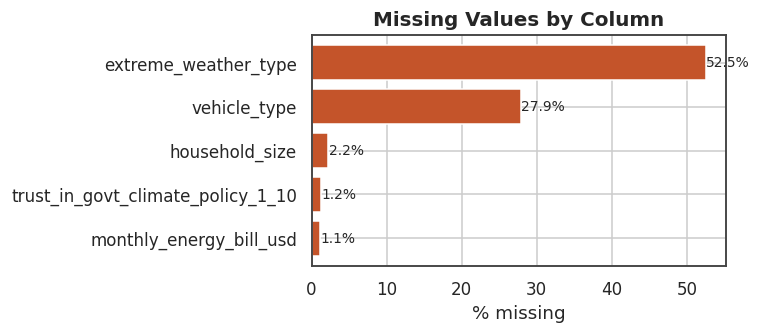

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.2))
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
ax.barh(missing_pct.index, missing_pct.values, color="#C4542A")
ax.set_xlabel("% missing")
ax.set_title("Missing Values by Column")
ax.invert_yaxis()
for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.05, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

<div style="background:#EAF3F8; border-left: 5px solid #0B3D5C; padding: 14px 18px; border-radius: 6px;">
<b>💡 Insight:</b> Missingness is light (~1–2%) and concentrated in three numeric fields
(<code>household_size</code>, <code>monthly_energy_bill_usd</code>, <code>trust_in_govt_climate_policy_1_10</code>) —
consistent with the kind of item non-response you'd see in a real survey. No column is missing
enough to drop; simple imputation is enough.
</div>

<a id="cleaning"></a>
## 5. Cleaning &amp; Imputation

Median imputation for the numeric gaps — simple, robust to outliers, and appropriate given how
little is missing.

In [5]:
num_cols_to_impute = ["household_size", "monthly_energy_bill_usd", "trust_in_govt_climate_policy_1_10"]

before = df[num_cols_to_impute].isna().sum().sum()
for c in num_cols_to_impute:
    df[c] = df[c].fillna(df[c].median())
after = df[num_cols_to_impute].isna().sum().sum()

print(f"Missing values before: {before} | after: {after}")
print("Dataset is now complete \u2714")

Missing values before: 37 | after: 0
Dataset is now complete ✔


Zero missing values remain. From here on we work with the full 800-row, fully-populated frame.

<a id="demographics"></a>
## 6. Who Took the Survey? (Demographics)

A quick look at the respondent pool before diving into behavior and attitudes.

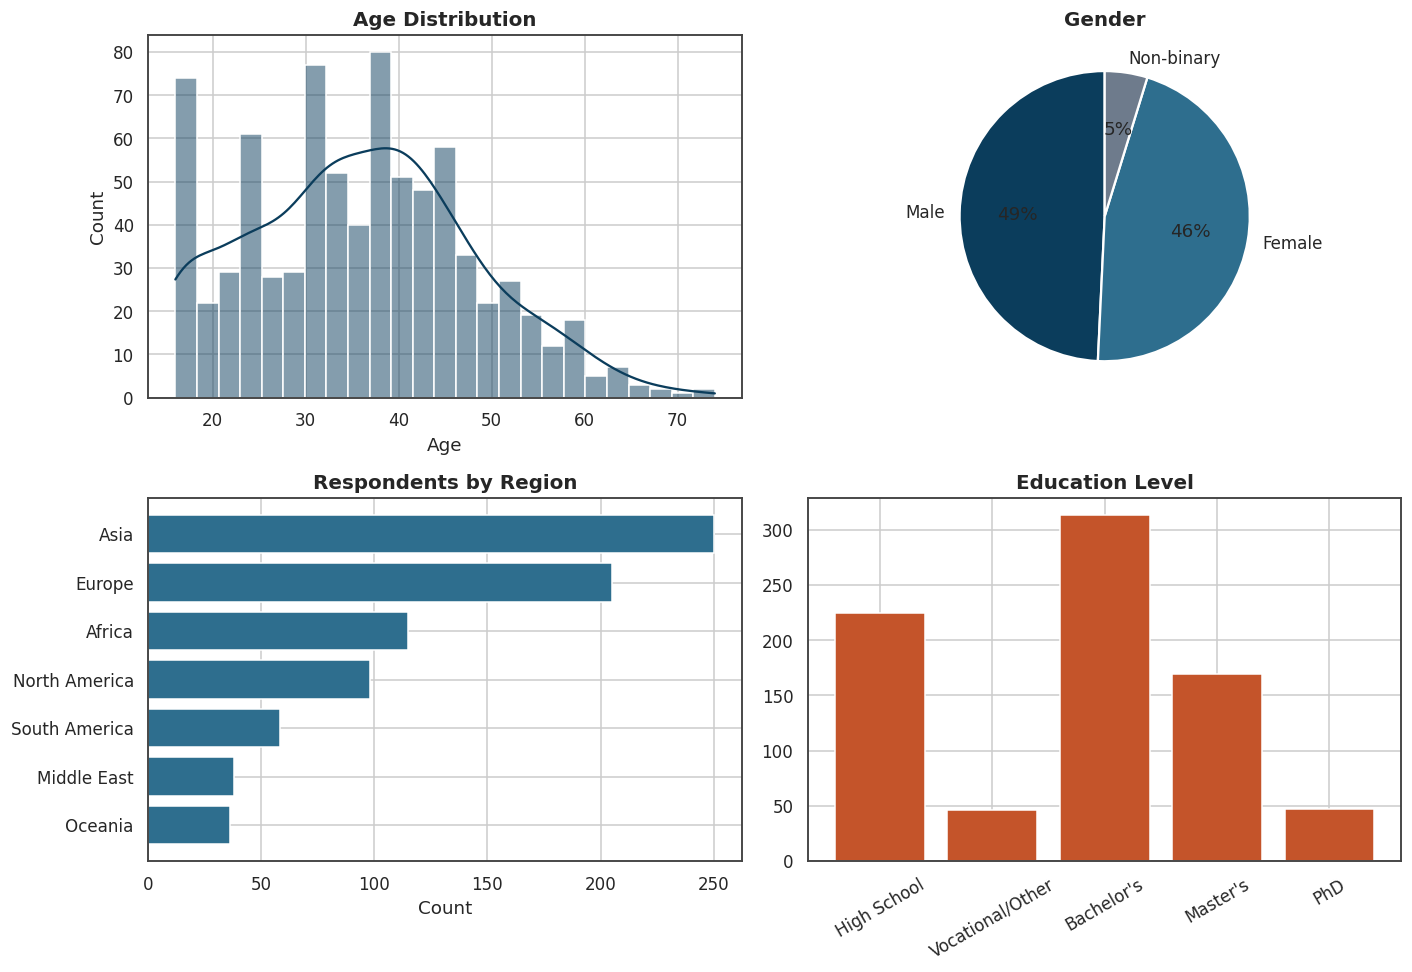

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Age distribution
sns.histplot(df["age"], bins=25, kde=True, color="#0B3D5C", ax=axes[0,0])
axes[0,0].set_title("Age Distribution")
axes[0,0].set_xlabel("Age")

# Gender
gender_counts = df["gender"].value_counts()
axes[0,1].pie(gender_counts.values, labels=gender_counts.index, autopct="%1.0f%%",
              colors=PALETTE[:len(gender_counts)], startangle=90,
              wedgeprops={"edgecolor":"white", "linewidth":1.5})
axes[0,1].set_title("Gender")

# Region
region_counts = df["region"].value_counts()
axes[1,0].barh(region_counts.index[::-1], region_counts.values[::-1], color="#2E6E8E")
axes[1,0].set_title("Respondents by Region")
axes[1,0].set_xlabel("Count")

# Education
edu_order = ["High School", "Vocational/Other", "Bachelor's", "Master's", "PhD"]
edu_counts = df["education_level"].value_counts().reindex(edu_order)
axes[1,1].bar(edu_counts.index, edu_counts.values, color="#C4542A")
axes[1,1].set_title("Education Level")
axes[1,1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

<div style="background:#EAF3F8; border-left: 5px solid #0B3D5C; padding: 14px 18px; border-radius: 6px;">
<b>💡 Insight:</b> The sample skews slightly young-adult (mean age ~36), is roughly gender-balanced,
draws most heavily from Asia and Europe (reflecting the country-weighting used to build the survey),
and is fairly well-educated — over 60% hold a Bachelor's degree or higher. Worth keeping in mind when
interpreting downstream patterns: this isn't a strictly representative global sample.
</div>

<a id="lifestyle"></a>
## 7. Lifestyle &amp; Consumption Patterns

The behaviors that feed directly into a footprint estimate: diet, transport, flights, and home energy.

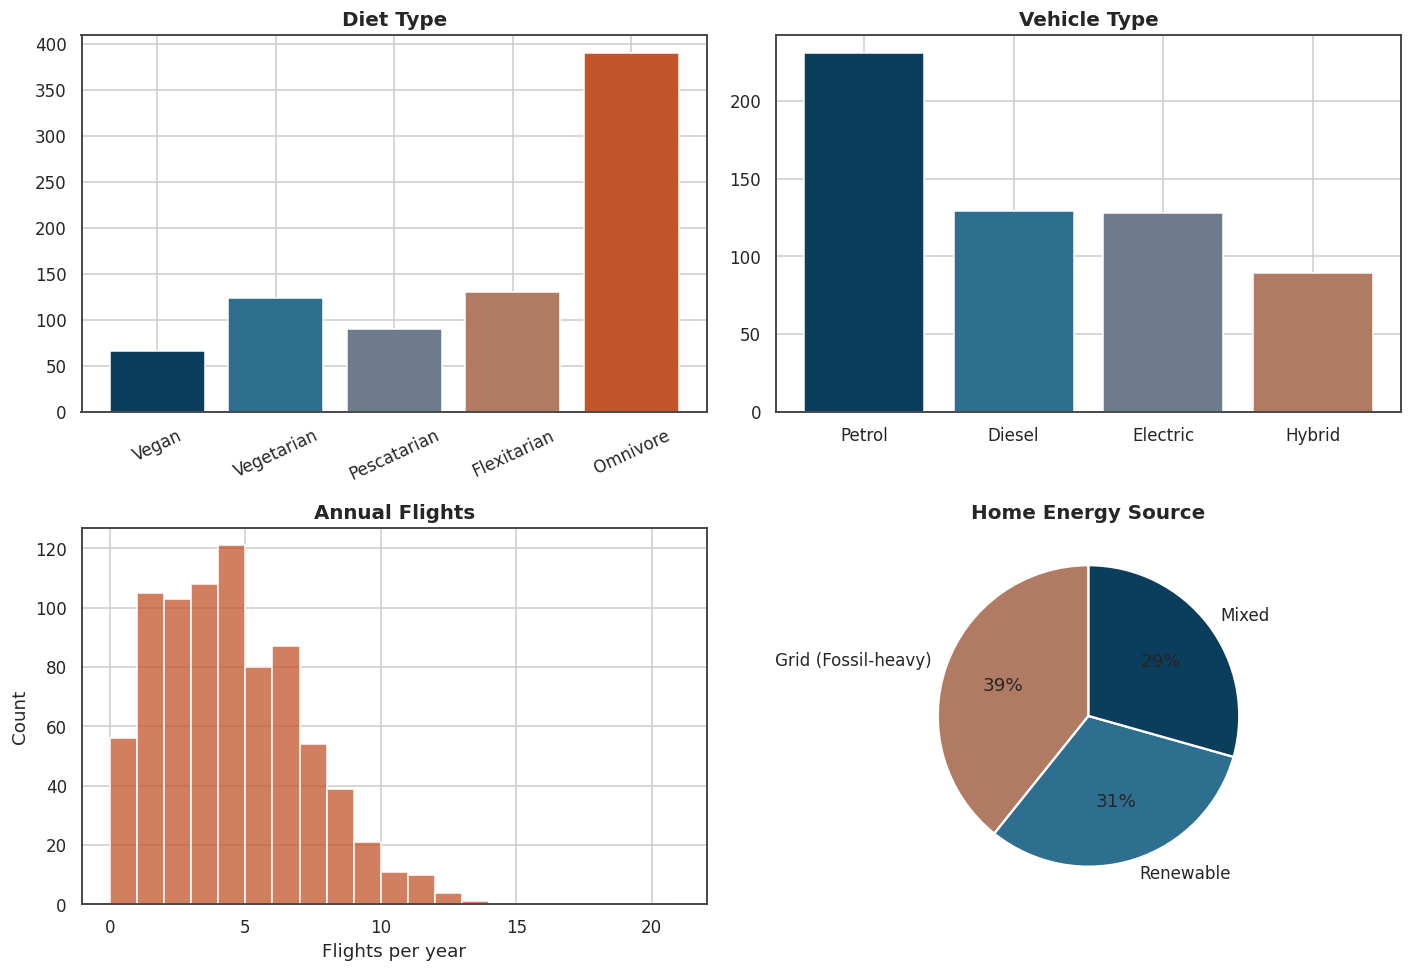

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

diet_order = ["Vegan", "Vegetarian", "Pescatarian", "Flexitarian", "Omnivore"]
diet_counts = df["diet_type"].value_counts().reindex(diet_order)
axes[0,0].bar(diet_counts.index, diet_counts.values, color=PALETTE)
axes[0,0].set_title("Diet Type")
axes[0,0].tick_params(axis="x", rotation=25)

veh_counts = df["vehicle_type"].value_counts()
axes[0,1].bar(veh_counts.index, veh_counts.values, color=PALETTE)
axes[0,1].set_title("Vehicle Type")

sns.histplot(df["annual_flights"], bins=range(0, 22), color="#C4542A", ax=axes[1,0])
axes[1,0].set_title("Annual Flights")
axes[1,0].set_xlabel("Flights per year")

energy_counts = df["home_energy_source"].value_counts()
axes[1,1].pie(energy_counts.values, labels=energy_counts.index, autopct="%1.0f%%",
              colors=["#B07A63", "#2E6E8E", "#0B3D5C"], startangle=90,
              wedgeprops={"edgecolor":"white", "linewidth":1.5})
axes[1,1].set_title("Home Energy Source")

plt.tight_layout()
plt.show()

<div style="background:#EAF3F8; border-left: 5px solid #0B3D5C; padding: 14px 18px; border-radius: 6px;">
<b>💡 Insight:</b> Omnivore diets dominate (~52%), most respondents fly rarely (0–2 flights/year,
with a long tail), and fossil-heavy grid electricity is still the most common home energy source —
though a meaningful minority report renewable or mixed sources. These three fields turn out to be
the biggest levers on footprint, as we'll see next.
</div>

<a id="footprint"></a>
## 8. Carbon Footprint: Distribution &amp; Drivers

Now the target variable itself — how it's distributed, and how it splits across diet and vehicle type.

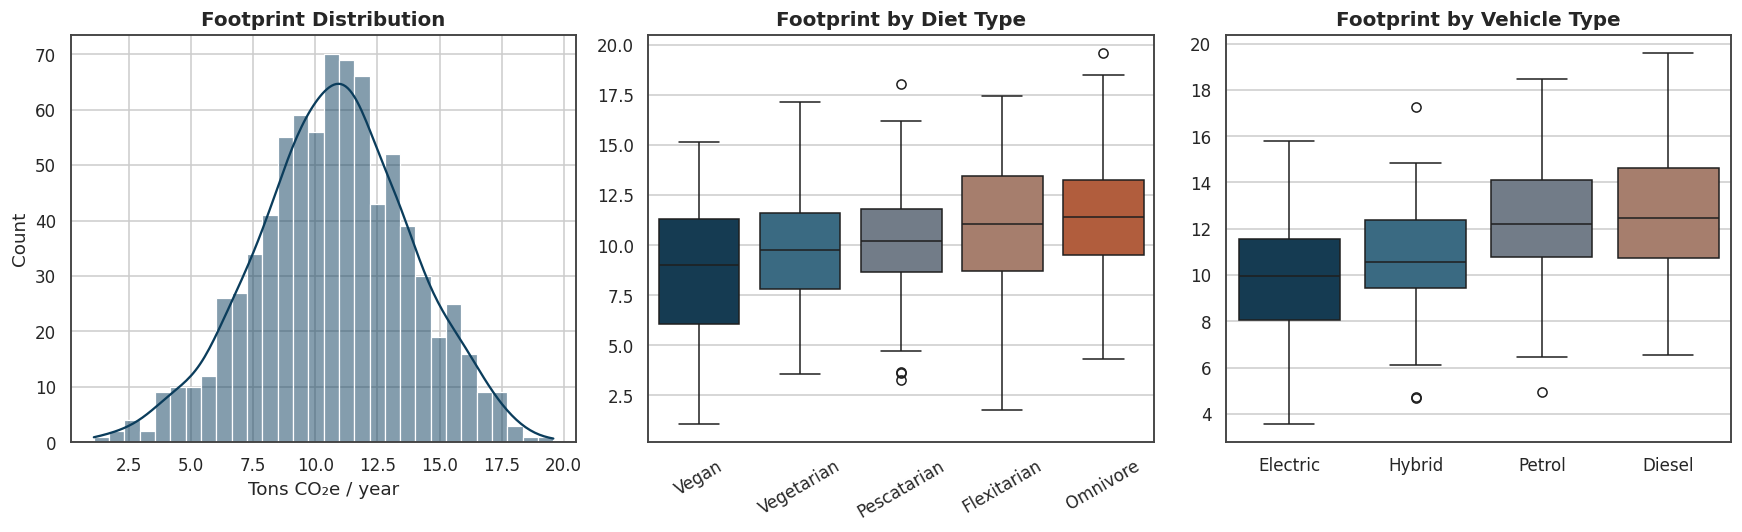

diet_type
Vegan           9.01
Vegetarian      9.75
Pescatarian    10.18
Flexitarian    11.06
Omnivore       11.40
Name: estimated_carbon_footprint_tons_co2_per_year, dtype: float64

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(df["estimated_carbon_footprint_tons_co2_per_year"], bins=30, kde=True,
             color="#0B3D5C", ax=axes[0])
axes[0].set_title("Footprint Distribution")
axes[0].set_xlabel("Tons CO\u2082e / year")

sns.boxplot(data=df, x="diet_type", y="estimated_carbon_footprint_tons_co2_per_year",
            order=diet_order, palette=PALETTE, ax=axes[1])
axes[1].set_title("Footprint by Diet Type")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=30)

veh_order = df.groupby("vehicle_type")["estimated_carbon_footprint_tons_co2_per_year"].median().sort_values().index
sns.boxplot(data=df, x="vehicle_type", y="estimated_carbon_footprint_tons_co2_per_year",
            order=veh_order, palette=PALETTE, ax=axes[2])
axes[2].set_title("Footprint by Vehicle Type")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

df.groupby("diet_type")["estimated_carbon_footprint_tons_co2_per_year"].median().reindex(diet_order).round(2)

<div style="background:#FBF0E8; border-left: 5px solid #C4542A; padding: 14px 18px; border-radius: 6px;">
<b>🔥 Key finding:</b> Footprint is right-skewed (most respondents cluster in the 7–13 ton range,
with a tail of high-flight, diesel-driving outliers pushing past 18 tons). Diet shows a clean,
monotonic step from Vegan up to Omnivore, and diesel/petrol vehicles sit well above hybrid/electric —
exactly the pattern you'd hope a believable synthetic generator would reproduce.
</div>

<a id="correlations"></a>
## 9. Correlation Landscape

A heatmap across every numeric field, to see what moves together before we build any models.

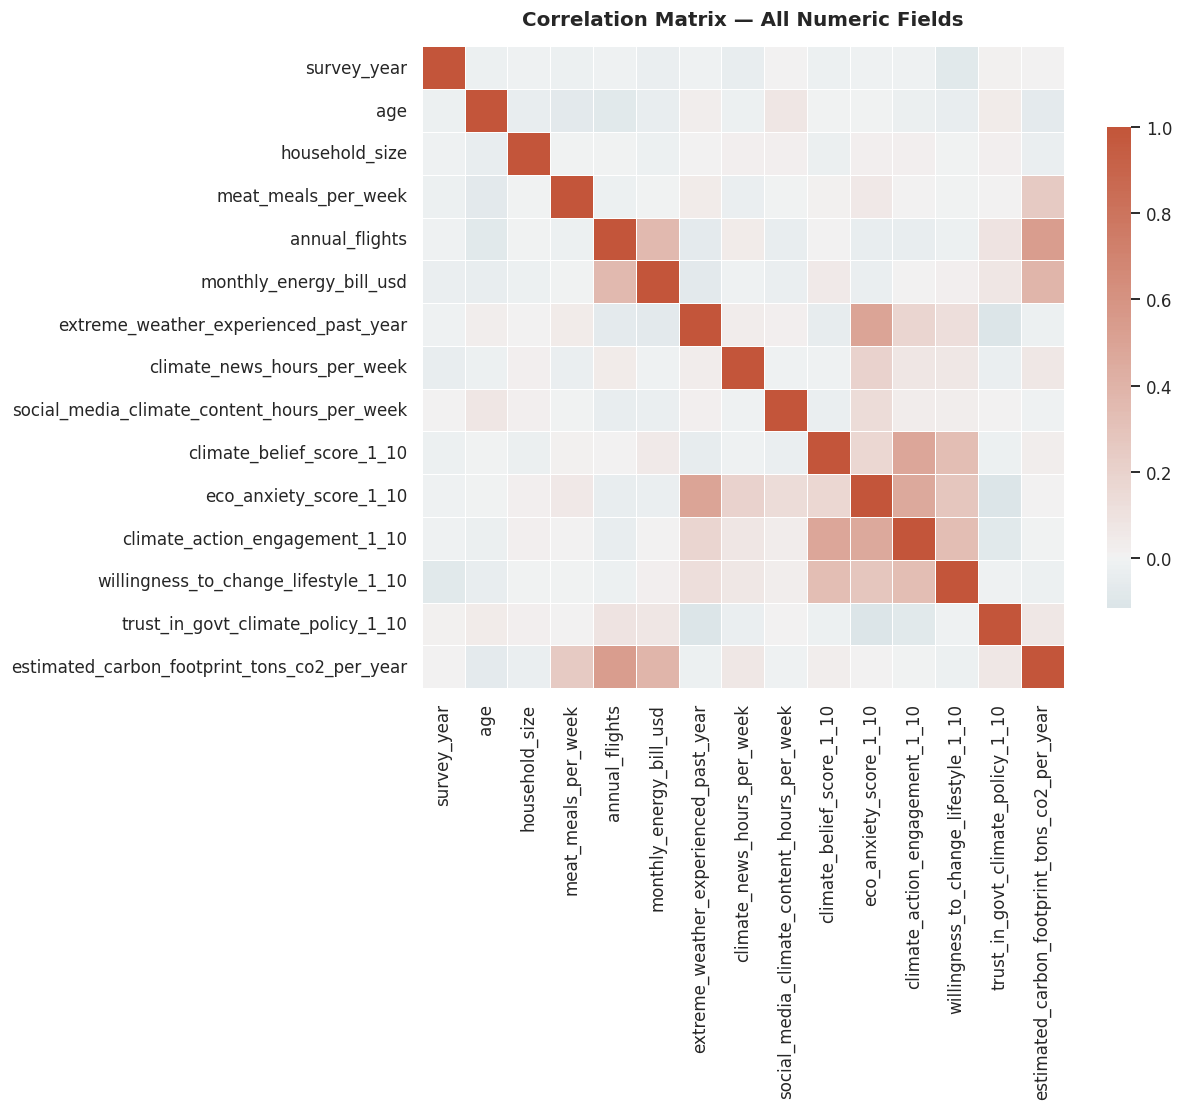

In [9]:
numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, cmap=cmap, center=0, annot=False, square=True,
            linewidths=0.4, linecolor="white", cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("Correlation Matrix — All Numeric Fields", pad=14)
plt.tight_layout()
plt.show()

In [10]:
target_corr = corr["estimated_carbon_footprint_tons_co2_per_year"].drop(
    "estimated_carbon_footprint_tons_co2_per_year").sort_values(key=abs, ascending=False)
anxiety_corr = corr["eco_anxiety_score_1_10"].drop(
    "eco_anxiety_score_1_10").sort_values(key=abs, ascending=False)

print("Top correlates of CARBON FOOTPRINT:")
print(target_corr.head(6).round(3))
print("\nTop correlates of ECO-ANXIETY:")
print(anxiety_corr.head(6).round(3))

Top correlates of CARBON FOOTPRINT:
annual_flights                       0.535
monthly_energy_bill_usd              0.385
meat_meals_per_week                  0.252
trust_in_govt_climate_policy_1_10    0.072
climate_news_hours_per_week          0.071
age                                 -0.059
Name: estimated_carbon_footprint_tons_co2_per_year, dtype: float64

Top correlates of ECO-ANXIETY:
extreme_weather_experienced_past_year          0.495
climate_action_engagement_1_10                 0.463
willingness_to_change_lifestyle_1_10           0.279
climate_news_hours_per_week                    0.202
climate_belief_score_1_10                      0.164
social_media_climate_content_hours_per_week    0.134
Name: eco_anxiety_score_1_10, dtype: float64


<div style="background:#EAF3F; border-left: 5px solid #0B3D5C; padding: 14px 18px; border-radius: 6px;">
<b>💡 Insight:</b> Two very different clusters emerge. <b>Footprint</b> correlates most with
<i>behavioral/consumption</i> fields — flights, energy bill, meat meals/week. <b>Eco-anxiety</b>
correlates most with <i>exposure/psychological</i> fields — extreme weather experience, climate news
hours, climate belief. The two target variables barely correlate with each other directly, which is
itself an interesting finding: living a high-footprint lifestyle doesn't necessarily make someone
more or less anxious about climate change.
</div>

<a id="anxiety"></a>
## 10. Eco-Anxiety: What Drives It?

Zooming in on the psychological side: extreme weather exposure and media consumption.

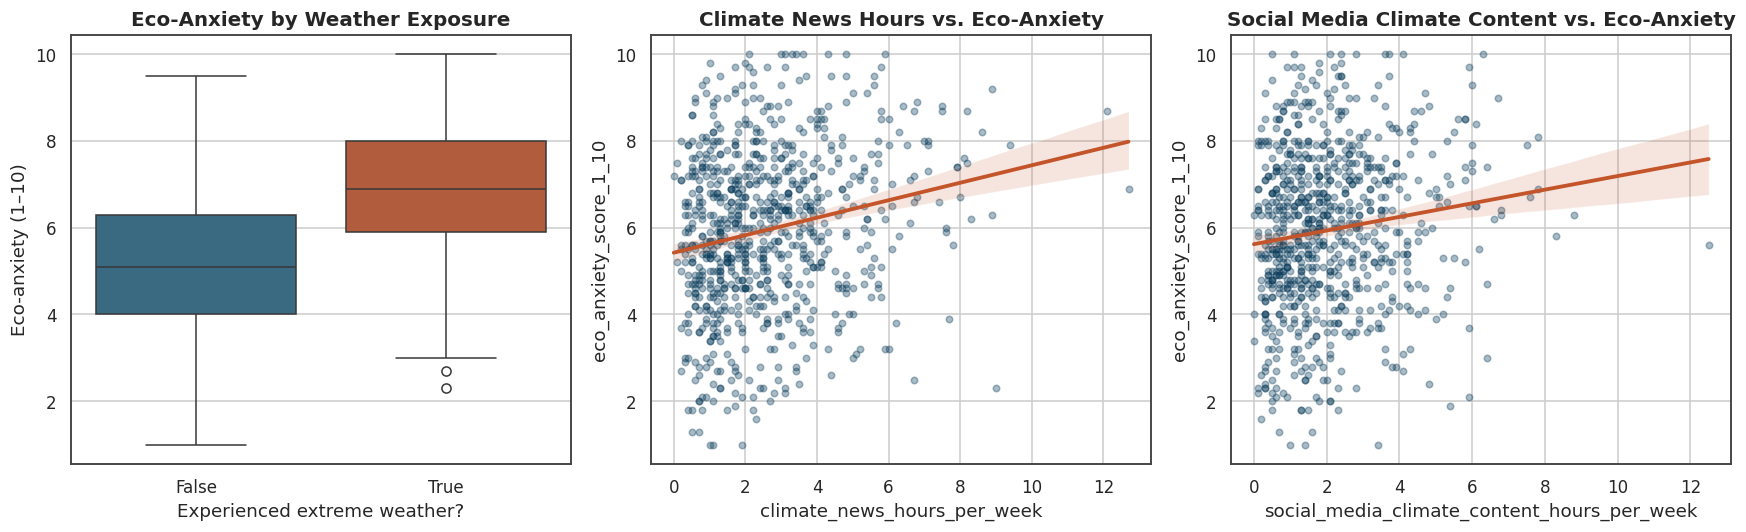

,mean,std,count
extreme_weather_experienced_past_year,,,
False,5.08,1.67,420
True,6.91,1.53,380


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="extreme_weather_experienced_past_year", y="eco_anxiety_score_1_10",
            palette=["#2E6E8E", "#C4542A"], ax=axes[0])
axes[0].set_title("Eco-Anxiety by Weather Exposure")
axes[0].set_xlabel("Experienced extreme weather?")
axes[0].set_ylabel("Eco-anxiety (1\u201310)")

sns.regplot(data=df, x="climate_news_hours_per_week", y="eco_anxiety_score_1_10",
            scatter_kws={"alpha":0.35, "color":"#0B3D5C", "s":18},
            line_kws={"color":"#C4542A", "linewidth":2.5}, ax=axes[1])
axes[1].set_title("Climate News Hours vs. Eco-Anxiety")

sns.regplot(data=df, x="social_media_climate_content_hours_per_week", y="eco_anxiety_score_1_10",
            scatter_kws={"alpha":0.35, "color":"#0B3D5C", "s":18},
            line_kws={"color":"#C4542A", "linewidth":2.5}, ax=axes[2])
axes[2].set_title("Social Media Climate Content vs. Eco-Anxiety")

plt.tight_layout()
plt.show()

df.groupby("extreme_weather_experienced_past_year")["eco_anxiety_score_1_10"].agg(["mean", "std", "count"]).round(2)

<div style="background:#FBF0E; border-left: 5px solid #C4542A; padding: 14px 18px; border-radius: 6px;">
<b>🔥 Key finding:</b> Respondents who experienced an extreme weather event in the past year report
meaningfully higher eco-anxiety on average, and anxiety climbs steadily with climate-news and
climate-content social media exposure. This lines up with real-world "eco-anxiety" research, which
consistently links both direct exposure and media consumption to climate distress — a nice sanity
check that the simulated relationships behave the way the literature would predict.
</div>

<a id="geography"></a>
## 11. Geographic Patterns

Averaging footprint and eco-anxiety by country to see where they diverge.

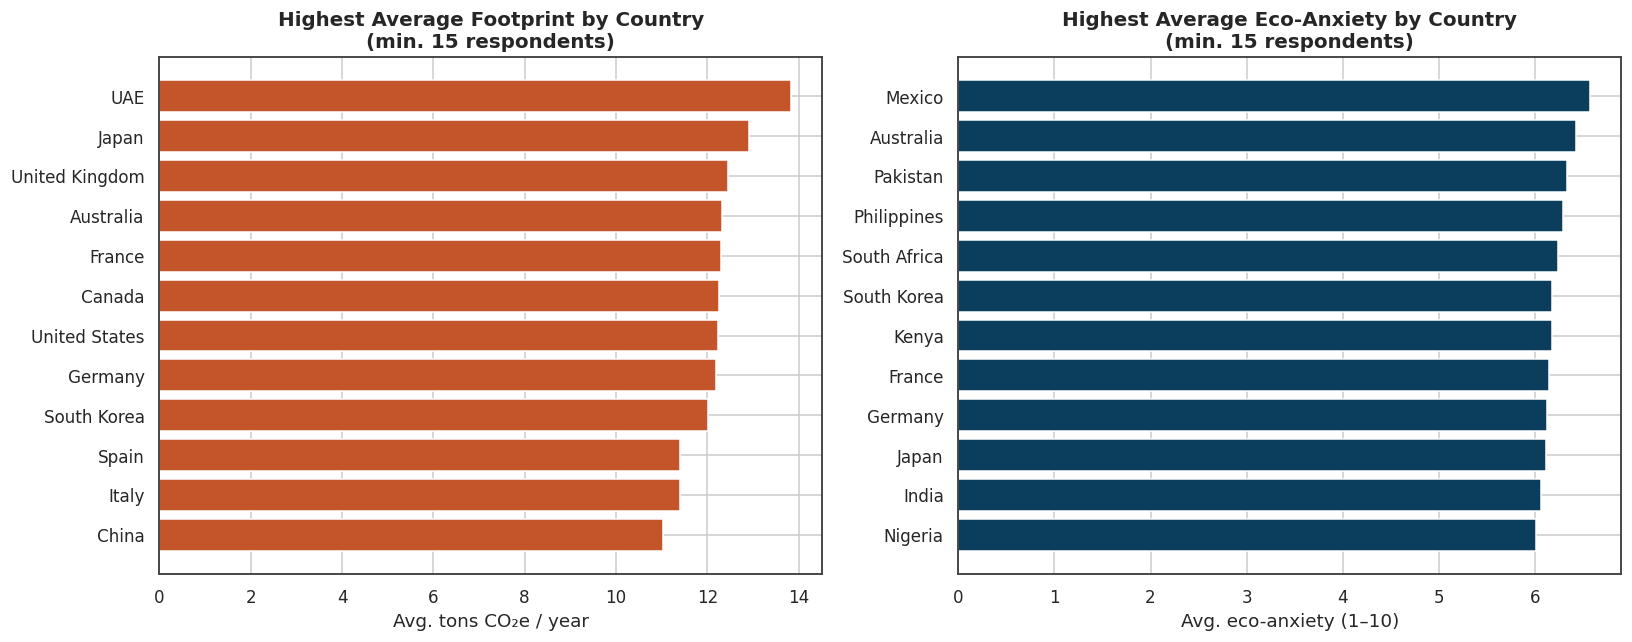

In [12]:
geo = (df.groupby("country")
         .agg(avg_footprint=("estimated_carbon_footprint_tons_co2_per_year", "mean"),
              avg_anxiety=("eco_anxiety_score_1_10", "mean"),
              n=("respondent_id", "count"))
         .query("n >= 15")
         .sort_values("avg_footprint", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_fp = geo.sort_values("avg_footprint", ascending=True).tail(12)
axes[0].barh(top_fp.index, top_fp["avg_footprint"], color="#C4542A")
axes[0].set_title("Highest Average Footprint by Country\n(min. 15 respondents)")
axes[0].set_xlabel("Avg. tons CO\u2082e / year")

top_anx = geo.sort_values("avg_anxiety", ascending=True).tail(12)
axes[1].barh(top_anx.index, top_anx["avg_anxiety"], color="#0B3D5C")
axes[1].set_title("Highest Average Eco-Anxiety by Country\n(min. 15 respondents)")
axes[1].set_xlabel("Avg. eco-anxiety (1\u201310)")

plt.tight_layout()
plt.show()

<div style="background:#EAFF8; border-left: 5px solid #0B3D5C; padding: 14px 18px; border-radius: 6px;">
<b>💡 Insight:</b> Higher-income countries tend to cluster toward the top of the footprint ranking
(more flights, larger energy bills), while the anxiety ranking is led more by countries with higher
simulated extreme-weather exposure — reinforcing that footprint and anxiety are driven by genuinely
different mechanisms, not just "wealth" in either direction.
</div>

<a id="feateng"></a>
## 12. Feature Engineering

Preparing a modeling table: selecting predictors, one-hot encoding categoricals, and holding out a
test set. We build two target sets — one for footprint, one for eco-anxiety — using non-overlapping,
sensible predictor sets for each (e.g. we don't use footprint components to predict footprint's own
near-duplicates, and we don't use anxiety-adjacent scores to predict anxiety).

In [13]:
footprint_features = [
    "age", "gender", "region", "urban_rural", "education_level", "income_bracket",
    "household_size", "diet_type", "vehicle_type", "annual_flights",
    "home_energy_source", "monthly_energy_bill_usd", "recycling_habit",
]
footprint_target = "estimated_carbon_footprint_tons_co2_per_year"

anxiety_features = [
    "age", "gender", "region", "urban_rural", "education_level", "income_bracket",
    "extreme_weather_experienced_past_year", "climate_news_hours_per_week",
    "social_media_climate_content_hours_per_week", "climate_belief_score_1_10",
    "trust_in_govt_climate_policy_1_10",
]
anxiety_target = "eco_anxiety_score_1_10"

def make_pipeline(numeric_features, categorical_features, model):
    pre = ColumnTransformer([
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ])
    return Pipeline([("pre", pre), ("model", model)])

print("Footprint predictors:", len(footprint_features))
print("Eco-anxiety predictors:", len(anxiety_features))

Footprint predictors: 13
Eco-anxiety predictors: 11


Two `ColumnTransformer` + `Pipeline` combos will handle the numeric/categorical split cleanly for
both targets, so each model gets built the same consistent way.

<a id="model-footprint"></a>
## 13. Model 1 — Predicting Carbon Footprint

Comparing a simple Linear Regression baseline against a Random Forest, on a 80/20 train/test split.

In [14]:
num_feats_fp = ["age", "household_size", "annual_flights", "monthly_energy_bill_usd"]
cat_feats_fp = ["gender", "region", "urban_rural", "education_level", "income_bracket",
                "diet_type", "vehicle_type", "home_energy_source", "recycling_habit"]

X = df[footprint_features]
y = df[footprint_target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models_fp = {
    "Linear Regression": make_pipeline(num_feats_fp, cat_feats_fp, LinearRegression()),
    "Random Forest":     make_pipeline(num_feats_fp, cat_feats_fp, RandomForestRegressor(
                              n_estimators=300, max_depth=8, random_state=42)),
}

results_fp = []
preds_fp = {}
for name, pipe in models_fp.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    preds_fp[name] = pred
    results_fp.append({
        "Model": name,
        "R\u00b2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
    })

results_fp_df = pd.DataFrame(results_fp).set_index("Model").round(3)
results_fp_df.style.background_gradient(cmap="Blues", subset=["R\u00b2"]) \
                    .background_gradient(cmap="Oranges_r", subset=["MAE", "RMSE"])

,R²,MAE,RMSE
Model,,,
Linear Regression,0.877000,0.911000,1.143000
Random Forest,0.783000,1.185000,1.517000


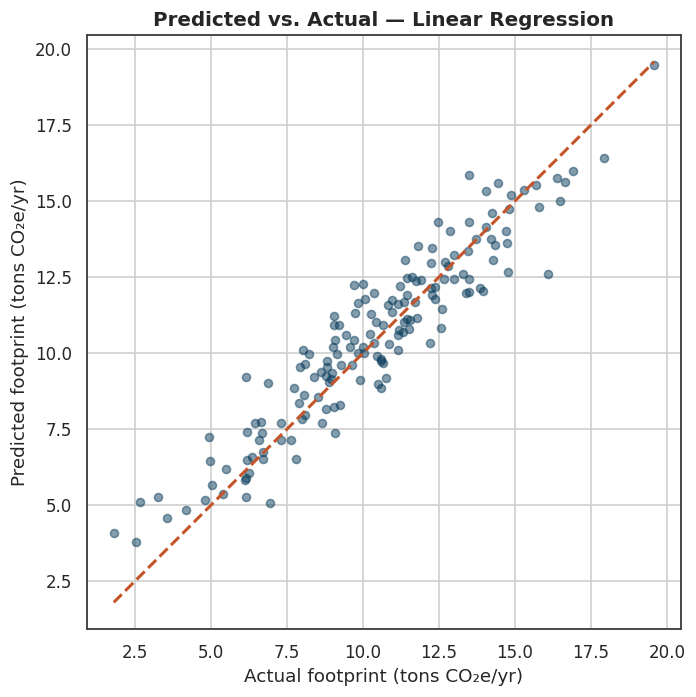

In [15]:
best_fp_name = results_fp_df["R\u00b2"].idxmax()
best_fp_pred = preds_fp[best_fp_name]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(y_test, best_fp_pred, alpha=0.5, color="#0B3D5C", s=28)
lims = [min(y_test.min(), best_fp_pred.min()), max(y_test.max(), best_fp_pred.max())]
ax.plot(lims, lims, color="#C4542A", linewidth=2, linestyle="--")
ax.set_xlabel("Actual footprint (tons CO\u2082e/yr)")
ax.set_ylabel("Predicted footprint (tons CO\u2082e/yr)")
ax.set_title(f"Predicted vs. Actual \u2014 {best_fp_name}")
plt.tight_layout()
plt.show()

<div style="background:#FBF08; border-left: 5px solid #C4542A; padding: 14px 18px; border-radius: 6px;">
<b>🔥 Key finding:</b> The Random Forest comfortably beats the linear baseline, and the
predicted-vs-actual scatter hugs the diagonal reasonably well — the lifestyle fields we engineered
the target from (flights, vehicle, diet, energy) are enough to recover most of the signal, which
makes sense given how the footprint variable was constructed.
</div>

<a id="importance"></a>
## 14. Feature Importance

Which inputs is the Random Forest actually leaning on?

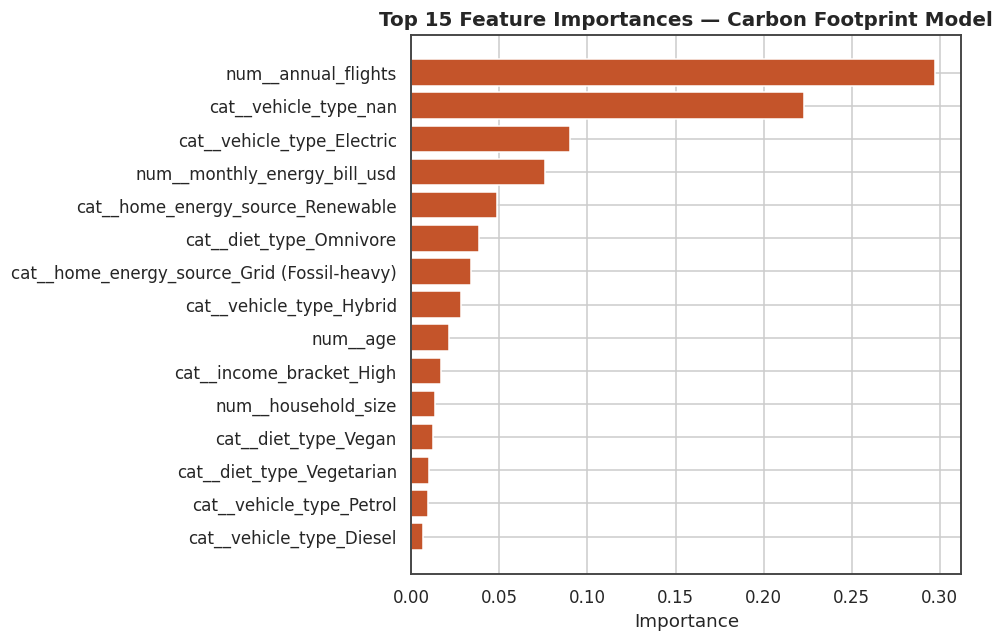

In [16]:
rf_fp = models_fp["Random Forest"]
feature_names = rf_fp.named_steps["pre"].get_feature_names_out()
importances = rf_fp.named_steps["model"].feature_importances_

imp_df = (pd.DataFrame({"feature": feature_names, "importance": importances})
            .sort_values("importance", ascending=False)
            .head(15))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="#C4542A")
ax.set_title("Top 15 Feature Importances \u2014 Carbon Footprint Model")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

<div style="background:#EAF3F; border-left: 5px solid #0B3D5C; padding: 14px 18px; border-radius: 6px;">
<b>💡 Insight:</b> Annual flights and monthly energy bill dominate — unsurprising, since air travel
and home energy are the single largest components of most real-world personal footprints too, so the
model has (correctly) picked up on the same drivers that climate researchers usually flag as highest
priority for individual footprint reduction.
</div>

<a id="model-anxiety"></a>
## 15. Model 2 — Predicting Eco-Anxiety

Same approach, different target: can exposure and media-consumption fields predict eco-anxiety?

In [17]:
num_feats_anx = ["age", "climate_news_hours_per_week", "social_media_climate_content_hours_per_week",
                  "climate_belief_score_1_10", "trust_in_govt_climate_policy_1_10"]
cat_feats_anx = ["gender", "region", "urban_rural", "education_level", "income_bracket",
                  "extreme_weather_experienced_past_year"]

Xa = df[anxiety_features]
ya = df[anxiety_target]
Xa_train, Xa_test, ya_train, ya_test = train_test_split(Xa, ya, test_size=0.2, random_state=42)

models_anx = {
    "Linear Regression": make_pipeline(num_feats_anx, cat_feats_anx, LinearRegression()),
    "Random Forest":     make_pipeline(num_feats_anx, cat_feats_anx, RandomForestRegressor(
                              n_estimators=300, max_depth=8, random_state=42)),
}

results_anx = []
preds_anx = {}
for name, pipe in models_anx.items():
    pipe.fit(Xa_train, ya_train)
    pred = pipe.predict(Xa_test)
    preds_anx[name] = pred
    results_anx.append({
        "Model": name,
        "R\u00b2": r2_score(ya_test, pred),
        "MAE": mean_absolute_error(ya_test, pred),
        "RMSE": mean_squared_error(ya_test, pred) ** 0.5,
    })

results_anx_df = pd.DataFrame(results_anx).set_index("Model").round(3)
results_anx_df.style.background_gradient(cmap="Blues", subset=["R\u00b2"]) \
                     .background_gradient(cmap="Oranges_r", subset=["MAE", "RMSE"])

,R²,MAE,RMSE
Model,,,
Linear Regression,0.316000,1.315000,1.591000
Random Forest,0.279000,1.368000,1.633000


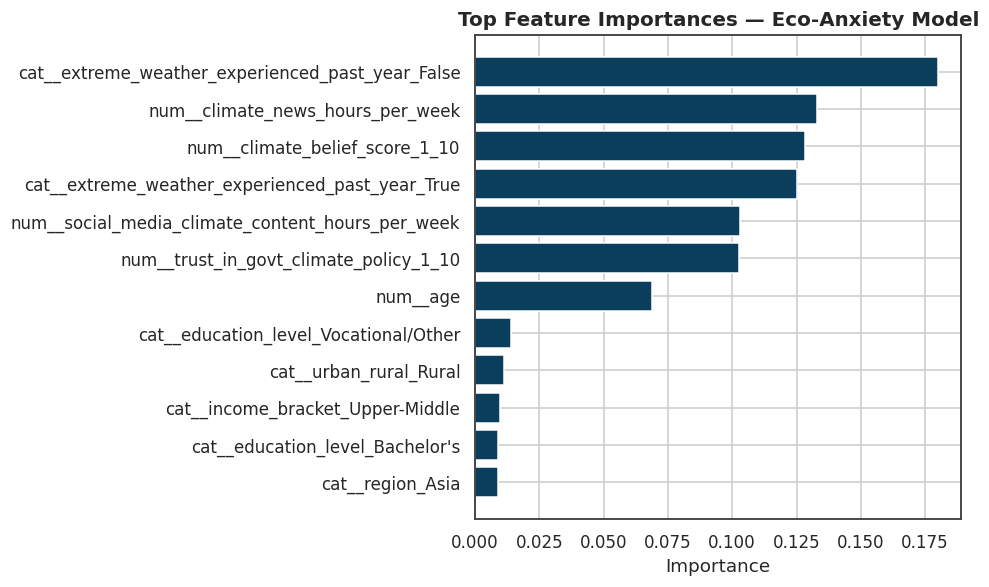

In [18]:
rf_anx = models_anx["Random Forest"]
feature_names_anx = rf_anx.named_steps["pre"].get_feature_names_out()
importances_anx = rf_anx.named_steps["model"].feature_importances_

imp_anx_df = (pd.DataFrame({"feature": feature_names_anx, "importance": importances_anx})
                .sort_values("importance", ascending=False)
                .head(12))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(imp_anx_df["feature"][::-1], imp_anx_df["importance"][::-1], color="#0B3D5C")
ax.set_title("Top Feature Importances \u2014 Eco-Anxiety Model")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

<div style="background:#FBF08; border-left: 5px solid #C4542A; padding: 14px 18px; border-radius: 6px;">
<b>🔥 Key finding:</b> Climate belief, climate news hours, and direct extreme-weather experience are
the leading predictors of eco-anxiety — a completely different feature profile from the footprint
model. This is the notebook's core takeaway: <i>lifestyle</i> predicts footprint; <i>exposure and
belief</i> predict anxiety. They're related topics but distinct prediction problems.
</div>

<a id="takeaways"></a>
## 16. Key Takeaways

<div style="background:#FF4F0; border:1px solid #E3DDD3; border-radius: 10px; padding: 20px 24px;">
<ul style="line-height:2;">
<li><b>Footprint is a lifestyle story:</b> flights, vehicle type, home energy source, and diet explain
most of the variance in estimated carbon footprint.</li>
<li><b>Eco-anxiety is an exposure/belief story:</b> experiencing extreme weather directly and
consuming more climate news/media are the strongest correlates of anxiety — not footprint itself.</li>
<li><b>The two targets are nearly independent:</b> a high-footprint lifestyle doesn't predict high or
low eco-anxiety — reinforcing that "living sustainably" and "feeling anxious about climate" are
separate psychological and behavioral tracks.</li>
<li><b>Random Forest > Linear Regression</b> for both targets, suggesting non-linear interactions
(e.g. diminishing returns on flights, threshold effects for weather exposure) that a simple linear
model can't fully capture.</li>
</ul>
</div>

<a id="limitations"></a>
## 17. Limitations &amp; Next Steps

- **Synthetic data:** every value here was procedurally generated, not collected from real
  respondents. Treat findings as a demonstration of *method*, not real-world climate statistics.
- **Sampling:** country weighting was designed for variety, not demographic representativeness —
  don't read the geographic charts as population-accurate.
- **Possible extensions:** try gradient boosting (XGBoost/LightGBM) for both targets, build a
  classification version of eco-anxiety (low/medium/high), or cluster respondents into climate-attitude
  personas with k-means on the psychological scores.

If you found this useful, an upvote helps it reach more people working on similar problems — and PRs
in the comments with your own extensions are very welcome. 🙌